In [37]:
import os
from pathlib import Path
cwd = Path.cwd()

if cwd.name == "notebooks":
    os.chdir(cwd.parent)

In [38]:
import os, math, json
from pathlib import Path
import numpy as np
import torch
import pandas as pd

import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.spatial.distance import jensenshannon

In [39]:
RESULTS_PATH = "data/experiments/group_cls_patching/vitbase_neutrality/group_patching_results.pt"  # <- change me

res = torch.load(RESULTS_PATH, map_location="cpu", weights_only=False)
print(res.keys())
print("has original:", "original" in res, "| has patched:", "patched" in res)

# # quick peek
print("streams in layer_0:", list(res["patched"]["layer_1"].keys()))
first_stream = list(res["patched"]["layer_1"].keys())[0]
first_combo = list(res["patched"]["layer_1"][first_stream].keys())[0]
print("example combo:", first_combo)
print("keys inside combo:", res["patched"]["layer_1"][first_stream][first_combo].keys())


dict_keys(['original', 'corrupted', 'patched', 'emotion_map', 'groups_json_path', 'file_key', 'groups', 'combo_names'])
has original: True | has patched: True
streams in layer_0: ['block_output', 'attention_output', 'mlp_activation']
example combo: skin
keys inside combo: dict_keys(['patched_groups', 'patched_patch_indices', 'final_probs', 'probe_next_layer_probs'])


In [40]:
res["patched"]["layer_1"][first_stream][first_combo]['probe_next_layer_probs']

array([[4.39777744e-02, 1.00729090e-08, 9.45859053e-01, 1.01567659e-02,
        1.96535136e-06, 4.43118703e-06]])

In [41]:
EPS = 1e-12

def to_np_probs(x):
    """Convert stored probs to numpy [C]. Accepts np [1,C], torch [1,C], list, etc."""
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    if x.ndim == 2 and x.shape[0] == 1:
        x = x[0]
    assert x.ndim == 1, f"expected [C], got {x.shape}"
    # numeric safety
    x = np.clip(x, EPS, 1.0)
    x = x / x.sum()
    return x

def kl_div(p, q):
    """KL(p || q)"""
    p = np.clip(p, EPS, 1.0); p = p / p.sum()
    q = np.clip(q, EPS, 1.0); q = q / q.sum()
    return float(np.sum(p * (np.log(p) - np.log(q))))

def js_div(p, q):
    """Jensen-Shannon divergence (base e)."""
    p = np.clip(p, EPS, 1.0); p = p / p.sum()
    q = np.clip(q, EPS, 1.0); q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5 * kl_div(p, m) + 0.5 * kl_div(q, m)

def l1_dist(p, q):
    return float(np.sum(np.abs(p - q)))

def entropy(p):
    p = np.clip(p, EPS, 1.0); p = p / p.sum()
    return float(-np.sum(p * np.log(p)))

def top1(p):
    return int(np.argmax(p))

def delta_p_correct(p_base, p_new, correct_idx):
    return float(p_new[correct_idx] - p_base[correct_idx])

def delta_p_pred(p_base, p_new):
    pred = top1(p_base)
    return float(p_new[pred] - p_base[pred])

def flip(base_probs, new_probs):
    return top1(base_probs) != top1(new_probs)


In [42]:
orig_final = to_np_probs(res["original"]["final_probs"])
corr_final = to_np_probs(res["corrupted"]["final_probs"])

correct_idx = None
md = res["original"].get("metadata", {})
if isinstance(md, dict):
    val = md['emotion']
    if isinstance(val, str) and "emotion_map" in res:
        rev = {v[0]:k for k,v in res["emotion_map"].items()}
        if val in rev:
            correct_idx = int(rev[val])

if correct_idx is None:
    correct_idx = int(np.argmax(orig_final))
    print("WARNING: correct_idx not found in metadata. Using baseline top-1 as 'correct' =", correct_idx)
else:
    print("correct_idx from metadata =", correct_idx)

print("orig top1:", np.argmax(orig_final), "corr top1:", np.argmax(corr_final), "correct_idx:", correct_idx)


correct_idx from metadata = 1
orig top1: 1 corr top1: 2 correct_idx: 1


In [43]:
res["emotion_map"]

{0: 'neutrality',
 1: 'happiness',
 2: 'sadness',
 3: 'anger',
 4: 'disgust',
 5: 'fear'}

In [44]:
rows = []

base = orig_final

for layer_key, layer_dict in tqdm(res["patched"].items()):
    layer_idx = int(layer_key.split("_")[1])
    for stream, combos in layer_dict.items():
        for combo_name, payload in combos.items():
            p_final = to_np_probs(payload.get("final_probs"))
            p_probe = to_np_probs(payload.get("probe_next_layer_probs"))

            row = {
                "layer": layer_idx,
                "stream": stream,
                "combo": combo_name,
                "n_patches": len(payload.get("patched_patch_indices", [])),
                "final_top1": top1(p_final),
                "final_flip": flip(base, p_final),
                "delta_p_correct": delta_p_correct(base, p_final, correct_idx),
                "delta_p_pred": delta_p_pred(base, p_final),
                "KL_base_to_patched": kl_div(base, p_final),
                "KL_patched_to_base": kl_div(p_final, base),
                "JS": js_div(base, p_final),
                "L1": l1_dist(base, p_final),
                "H_base": entropy(base),
                "H_patched": entropy(p_final),
                "delta_entropy": entropy(p_final) - entropy(base),
            }

            if p_probe is not None:
                row.update({
                    "probe_top1": top1(p_probe),
                    "probe_flip_vs_base": flip(base, p_probe),
                    "probe_delta_p_correct": delta_p_correct(base, p_probe, correct_idx),
                    "probe_JS": js_div(base, p_probe),
                    "probe_L1": l1_dist(base, p_probe),
                })
            else:
                row.update({
                    "probe_top1": None,
                    "probe_flip_vs_base": None,
                    "probe_delta_p_correct": None,
                    "probe_JS": None,
                    "probe_L1": None,
                })

            rows.append(row)

df = pd.DataFrame(rows)
print(df.shape)
df.head()



100%|██████████| 12/12 [00:00<00:00, 118.31it/s]

(540, 20)


,layer,stream,combo,n_patches,final_top1,final_flip,delta_p_correct,delta_p_pred,KL_base_to_patched,KL_patched_to_base,JS,L1,H_base,H_patched,delta_entropy,probe_top1,probe_flip_vs_base,probe_delta_p_correct,probe_JS,probe_L1
0,0,block_output,skin,60,2,True,-1.000000e+00,-1.000000e+00,2.763102e+01,2.763098e+01,6.931472e-01,2.000000e+00,9.642096e-08,3.966511e-05,3.956868e-05,0.0,True,-0.971069,0.627226,1.942139
1,0,block_output,brows,4,1,False,9.927315e-10,9.927315e-10,1.278978e-10,1.156998e-10,3.026179e-11,1.985463e-09,9.642096e-08,7.719532e-08,-1.922564e-08,0.0,True,-0.983248,0.650451,1.966497
2,0,block_output,lips,12,0,True,-9.999999e-01,-9.999999e-01,1.608802e+01,2.749195e+01,6.931463e-01,2.000000e+00,9.642096e-08,1.385066e-01,1.385065e-01,0.0,True,-0.983952,0.651902,1.967904
3,0,block_output,neck,29,1,False,-5.124899e-07,-5.124899e-07,4.901432e-07,1.913260e-06,1.673528e-07,1.024980e-06,9.642096e-08,8.018318e-06,7.921897e-06,0.0,True,-0.973698,0.631980,1.947396
4,0,block_output,skin+brows,60,2,True,-1.000000e+00,-1.000000e+00,2.763102e+01,2.763098e+01,6.931472e-01,2.000000e+00,9.642096e-08,3.966511e-05,3.956868e-05,0.0,True,-0.971069,0.627226,1.942139


In [45]:
def show_top(df, metric, n=15, ascending=True):
    display(df.sort_values(metric, ascending=ascending).head(n)[
        ["layer","stream","combo","n_patches", metric, "final_top1", "final_flip"]
    ])

print("Top combos by MOST NEGATIVE delta_p_correct (bigger harm => more negative):")
show_top(df, "delta_p_correct", n=15, ascending=True)

print("\nTop combos by largest JS divergence:")
show_top(df, "JS", n=15, ascending=False)

print("\nFlip rate by combo (aggregated over layer+stream):")
flip_tbl = (
    df.groupby("combo")["final_flip"].mean()
      .sort_values(ascending=False)
      .reset_index()
      .rename(columns={"final_flip":"flip_rate"})
)
display(flip_tbl.head(40))


Top combos by MOST NEGATIVE delta_p_correct (bigger harm => more negative):


,layer,stream,combo,n_patches,delta_p_correct,final_top1,final_flip
0,0,block_output,skin,60,-1.0,2,True
34,0,mlp_activation,skin+brows,60,-1.0,2,True
35,0,mlp_activation,skin+lips,60,-1.0,2,True
36,0,mlp_activation,skin+neck,79,-1.0,2,True
39,0,mlp_activation,lips+neck,39,-1.0,2,True
40,0,mlp_activation,skin+brows+lips,60,-1.0,2,True
41,0,mlp_activation,skin+brows+neck,79,-1.0,2,True
42,0,mlp_activation,skin+lips+neck,79,-1.0,2,True
508,11,block_output,brows+lips+neck,42,-1.0,2,True
507,11,block_output,skin+lips+neck,79,-1.0,2,True



Top combos by largest JS divergence:


,layer,stream,combo,n_patches,JS,final_top1,final_flip
4,0,block_output,skin+brows,60,0.693147,2,True
0,0,block_output,skin,60,0.693147,2,True
10,0,block_output,skin+brows+lips,60,0.693147,2,True
5,0,block_output,skin+lips,60,0.693147,2,True
45,1,block_output,skin,60,0.693147,2,True
55,1,block_output,skin+brows+lips,60,0.693147,2,True
49,1,block_output,skin+brows,60,0.693147,2,True
50,1,block_output,skin+lips,60,0.693147,2,True
94,2,block_output,skin+brows,60,0.693147,2,True
95,2,block_output,skin+lips,60,0.693147,2,True



Flip rate by combo (aggregated over layer+stream):


,combo,flip_rate
0,skin+lips+neck,0.416667
1,skin+lips,0.416667
2,skin+brows+neck,0.416667
3,skin+brows+lips+neck,0.416667
4,skin+brows+lips,0.416667
5,skin+brows,0.416667
6,skin,0.416667
7,skin+neck,0.416667
8,brows+lips+neck,0.388889
9,lips+neck,0.388889


In [46]:
def heatmap_layer_combo(df_sub, metric, title=None):
    pivot = df_sub.pivot_table(index="combo", columns="layer", values=metric, aggfunc="mean")

    plt.figure(figsize=(12, max(4, 0.35 * len(pivot.index))))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label=metric)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
    plt.xlabel("Layer")
    plt.ylabel("Combo")
    plt.title(title or f"Heatmap: {metric}")
    plt.tight_layout()
    plt.show()
    return pivot


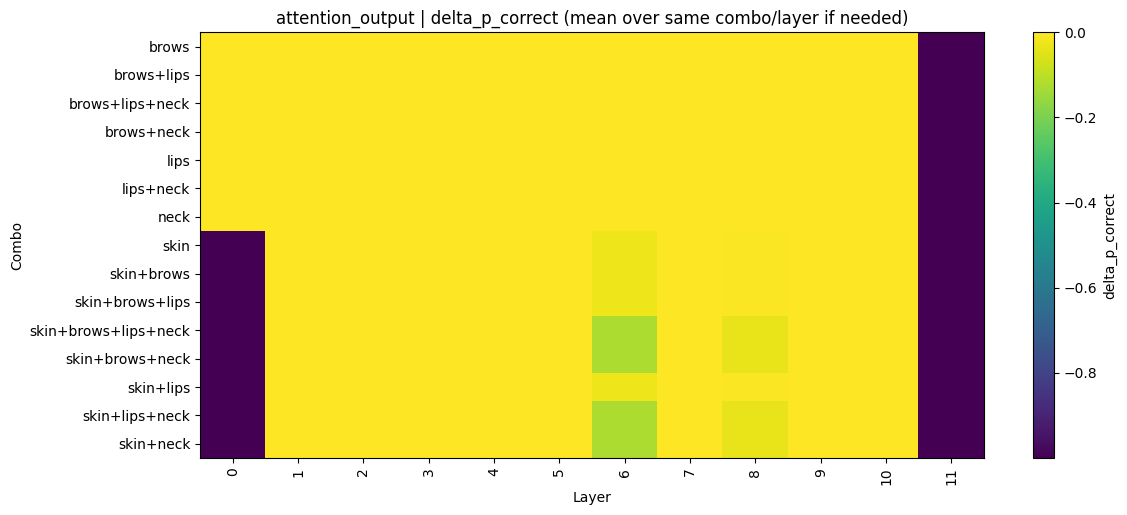

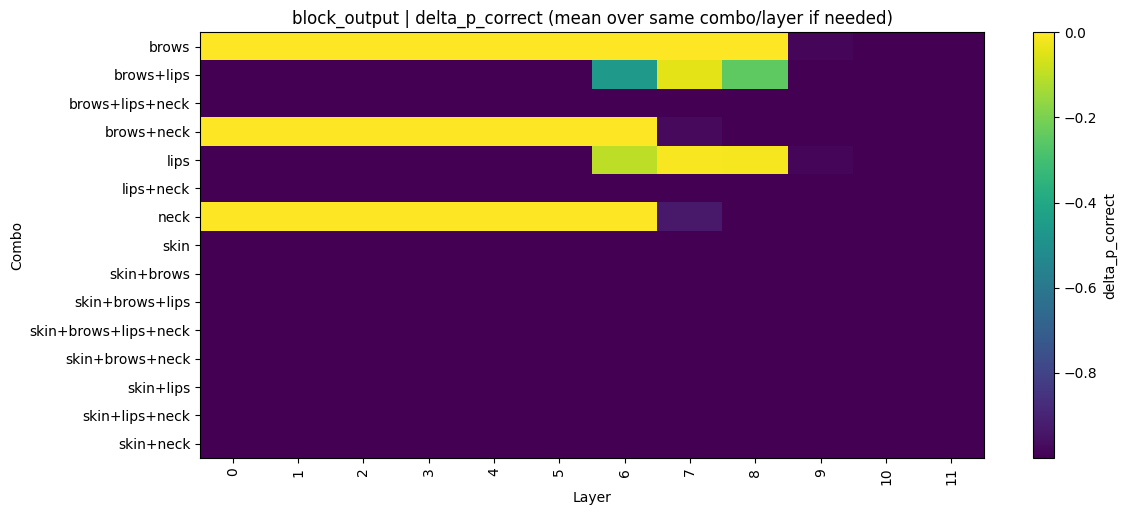

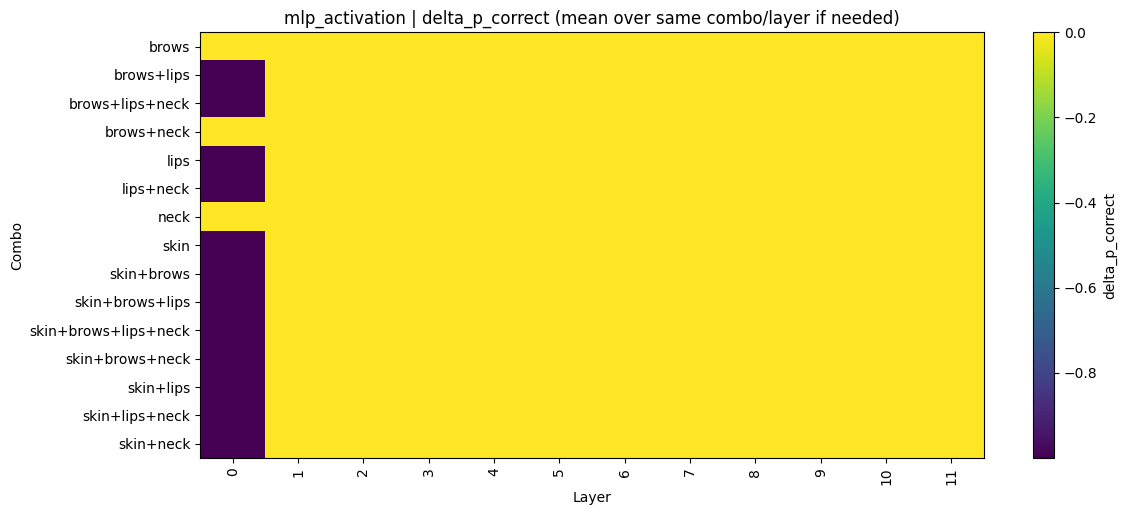

In [47]:
METRICS = ["delta_p_correct"]

for stream in sorted(df["stream"].unique()):
    df_s = df[df["stream"] == stream].copy()

    for m in METRICS:
        heatmap_layer_combo(
            df_s, m,
            title=f"{stream} | {m} (mean over same combo/layer if needed)"
        )


In [48]:
def best_layer_per_combo(df_sub, metric, mode="min"):
    out = []
    for combo, g in df_sub.groupby("combo"):
        if mode == "min":
            idx = g[metric].idxmin()
        else:
            idx = g[metric].idxmax()
        row = g.loc[idx, ["combo","layer","stream",metric,"n_patches","final_top1","final_flip"]].to_dict()
        out.append(row)
    return pd.DataFrame(out).sort_values(metric, ascending=(mode=="min"))

# For delta_p_correct => min is strongest negative
best_delta = best_layer_per_combo(df, "delta_p_correct", mode="min")
display(best_delta.head(20))



,combo,layer,stream,delta_p_correct,n_patches,final_top1,final_flip
0,brows,11,block_output,-1.0,4,2,True
1,brows+lips,11,block_output,-1.0,15,2,True
2,brows+lips+neck,0,block_output,-1.0,42,2,True
3,brows+neck,9,block_output,-1.0,32,2,True
4,lips,11,block_output,-1.0,12,2,True
5,lips+neck,0,block_output,-1.0,39,2,True
6,neck,10,block_output,-1.0,29,2,True
7,skin,0,block_output,-1.0,60,2,True
8,skin+brows,0,block_output,-1.0,60,2,True
9,skin+brows+lips,0,block_output,-1.0,60,2,True


Top combos: ['brows', 'brows+lips', 'brows+lips+neck', 'brows+neck', 'lips', 'lips+neck', 'neck', 'skin', 'skin+brows', 'skin+brows+lips', 'skin+brows+lips+neck', 'skin+brows+neck', 'skin+lips', 'skin+lips+neck', 'skin+neck']


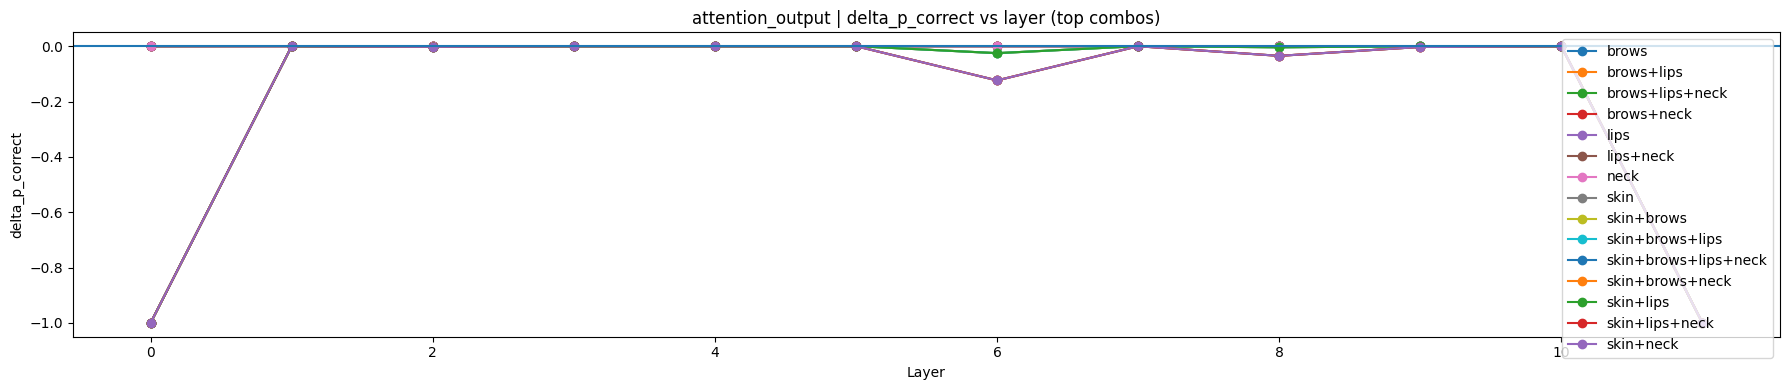

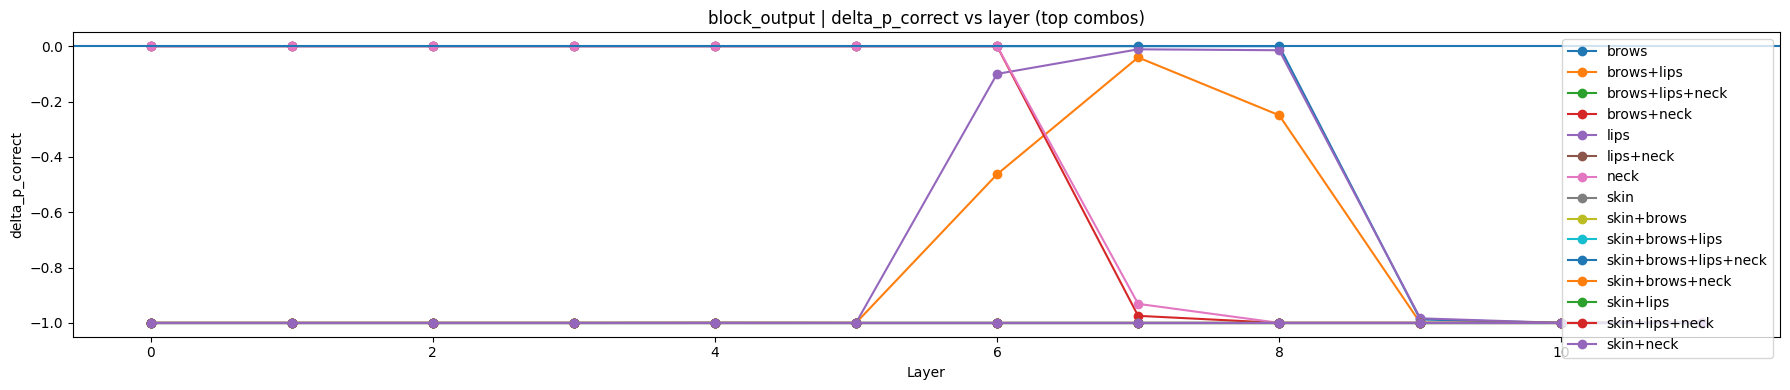

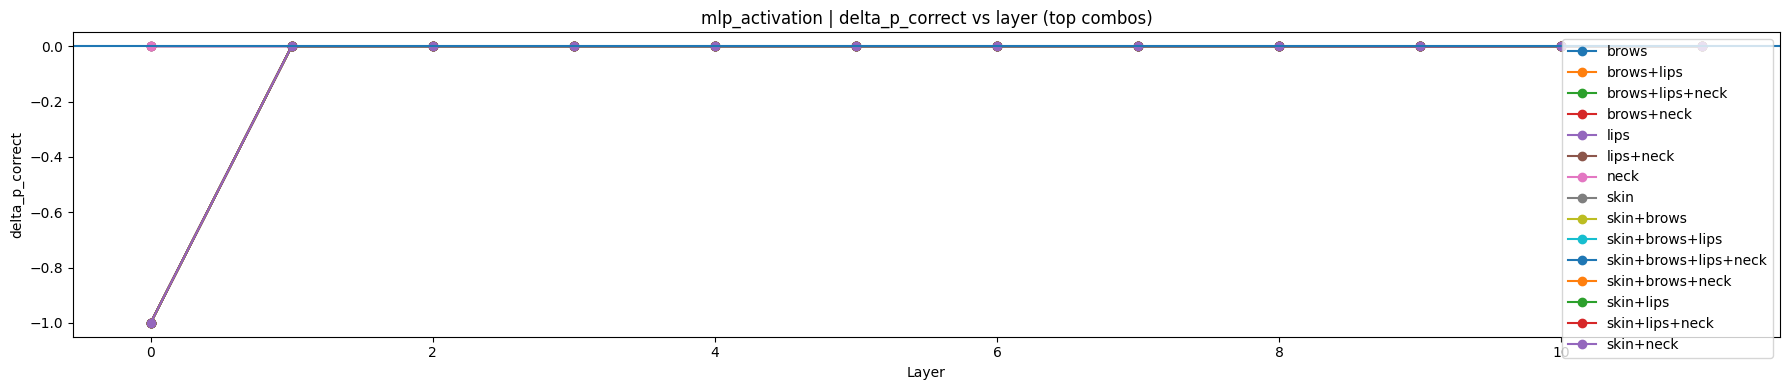

In [49]:
TOPK = 15

top_combos = (
    df.groupby("combo")["delta_p_correct"].min()
      .sort_values()
      .head(TOPK)
      .index
      .tolist()
)
print("Top combos:", top_combos)

metric = "delta_p_correct"  # try "JS", "L1"
for stream in sorted(df["stream"].unique()):
    plt.figure(figsize=(18,4))
    for combo in top_combos:
        g = df[(df["combo"]==combo) & (df["stream"]==stream)].sort_values("layer")
        plt.plot(g["layer"], g[metric], marker="o", label=combo)
    plt.axhline(0.0)
    plt.title(f"{stream} | {metric} vs layer (top combos)")
    plt.xlabel("Layer")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [50]:
agg = (
    df.groupby(["stream","combo"])
      .agg(
          worst_delta=("delta_p_correct","min"),   # most negative
          max_JS=("JS","max"),
          max_L1=("L1","max"),
          flip_rate=("final_flip","mean"),
          n_patches=("n_patches","max"),
      )
      .reset_index()
)

display(agg.sort_values("worst_delta").head(20))
display(agg.sort_values("max_JS", ascending=False).head(20))


,stream,combo,worst_delta,max_JS,max_L1,flip_rate,n_patches
15,block_output,brows,-1.0,0.693147,2.0,0.250000,4
22,block_output,skin,-1.0,0.693147,2.0,1.000000,60
29,block_output,skin+neck,-1.0,0.693147,2.0,1.000000,79
28,block_output,skin+lips+neck,-1.0,0.693147,2.0,1.000000,79
27,block_output,skin+lips,-1.0,0.693147,2.0,1.000000,60
26,block_output,skin+brows+neck,-1.0,0.693147,2.0,1.000000,79
25,block_output,skin+brows+lips+neck,-1.0,0.693147,2.0,1.000000,79
24,block_output,skin+brows+lips,-1.0,0.693147,2.0,1.000000,60
23,block_output,skin+brows,-1.0,0.693147,2.0,1.000000,60
18,block_output,brows+neck,-1.0,0.693147,2.0,0.416667,32


,stream,combo,worst_delta,max_JS,max_L1,flip_rate,n_patches
27,block_output,skin+lips,-1.0,0.693147,2.0,1.000000,60
22,block_output,skin,-1.0,0.693147,2.0,1.000000,60
23,block_output,skin+brows,-1.0,0.693147,2.0,1.000000,60
24,block_output,skin+brows+lips,-1.0,0.693147,2.0,1.000000,60
26,block_output,skin+brows+neck,-1.0,0.693147,2.0,1.000000,79
17,block_output,brows+lips+neck,-1.0,0.693147,2.0,1.000000,42
18,block_output,brows+neck,-1.0,0.693147,2.0,0.416667,32
15,block_output,brows,-1.0,0.693147,2.0,0.250000,4
16,block_output,brows+lips,-1.0,0.693147,2.0,0.750000,15
19,block_output,lips,-1.0,0.693147,2.0,0.750000,12


In [51]:
C = len(base)
base_top = int(np.argmax(base))

combo_shift_rows = []
for (stream, combo), g in df.groupby(["stream","combo"]):
    top_counts = g["final_top1"].value_counts()
    most_common_top = int(top_counts.index[0])
    frac = float(top_counts.iloc[0] / top_counts.sum())

    worst_row = g.loc[g["delta_p_correct"].idxmin()]
    combo_shift_rows.append({
        "stream": stream,
        "combo": combo,
        "n_patches": int(worst_row["n_patches"]),
        "baseline_top": base_top,
        "most_common_patched_top": most_common_top,
        "most_common_frac": frac,
        "worst_delta_p_correct": float(worst_row["delta_p_correct"]),
        "flip_rate": float(g["final_flip"].mean()),
    })

combo_shift = pd.DataFrame(combo_shift_rows)
display(combo_shift.sort_values(["worst_delta_p_correct"]).head(30))


,stream,combo,n_patches,baseline_top,most_common_patched_top,most_common_frac,worst_delta_p_correct,flip_rate
15,block_output,brows,4,1,1,0.750000,-1.000000,0.250000
22,block_output,skin,60,1,2,1.000000,-1.000000,1.000000
29,block_output,skin+neck,79,1,2,1.000000,-1.000000,1.000000
28,block_output,skin+lips+neck,79,1,2,1.000000,-1.000000,1.000000
27,block_output,skin+lips,60,1,2,1.000000,-1.000000,1.000000
26,block_output,skin+brows+neck,79,1,2,1.000000,-1.000000,1.000000
25,block_output,skin+brows+lips+neck,79,1,2,1.000000,-1.000000,1.000000
24,block_output,skin+brows+lips,60,1,2,1.000000,-1.000000,1.000000
23,block_output,skin+brows,60,1,2,1.000000,-1.000000,1.000000
18,block_output,brows+neck,32,1,1,0.583333,-1.000000,0.416667
